# Pipeline CNN + XGBoost — Classificação de Imagens ERCP

Abordagem híbrida para classificação de imagens de CPRE em 4 classes: Biliary_Leaks, Lithiasis, Normal, Stricture.

Extrai features da penúltima camada de uma CNN pré-treinada e usa XGBoost como classificador.

**Como usar:** define o modelo no CONFIG, corre todas as células, repete para cada backbone, depois corre o ensemble.

In [2]:
import os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from monai.transforms import (LoadImage, EnsureChannelFirst, Resize,
                               NormalizeIntensity, Lambda, ToTensor, Compose)

from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")
os.makedirs("./preds", exist_ok=True)

device = cuda


## Configuração

In [3]:
# pasta com o dataset já dividido (output do 1_split_dataset.ipynb)
DATASET_DIR = '../dataset'

# modelo a correr: deit3 / densenet / resnet / efficientnet / mobilenet
MODEL_TYPE = 'resnet'
MODEL_PTH = './models/resnet50.pth'

RUN_TAG = MODEL_TYPE
BATCH_SIZE = 16
NUM_WORKERS = 0
NUM_CLASS = 4
print(f"Modelo: {MODEL_TYPE.upper()}  |  ficheiro: {MODEL_PTH}")

Modelo: RESNET  |  ficheiro: ./models/resnet50.pth


## 1. Carregar listas de imagens (split patient-aware já feito)

In [6]:
phases = ['train', 'val', 'test']
class_names = sorted([x for x in os.listdir(os.path.join(DATASET_DIR, 'train'))
                      if os.path.isdir(os.path.join(DATASET_DIR, 'train', x))])
assert len(class_names) == NUM_CLASS, f"Esperava {NUM_CLASS} classes, encontrei {len(class_names)}: {class_names}"

data = {p: {'images': [], 'labels': []} for p in phases}
for p in phases:
    for i, cls in enumerate(class_names):
        d = os.path.join(DATASET_DIR, p, cls)
        for f in sorted(os.listdir(d)):
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                data[p]['images'].append(os.path.join(d, f))
                data[p]['labels'].append(i)

for p in phases:
    counts = np.bincount(data[p]['labels'], minlength=NUM_CLASS)
    print(f"{p}: {len(data[p]['images']):>4d} imgs  ->  {dict(zip(class_names, counts.tolist()))}")
print(f"classes (ordem): {class_names}")

train: 1067 imgs  ->  {'Biliary_Leaks': 110, 'Lithiasis': 505, 'Normal': 197, 'Stricture': 255}
val:  234 imgs  ->  {'Biliary_Leaks': 24, 'Lithiasis': 98, 'Normal': 59, 'Stricture': 53}
test:  267 imgs  ->  {'Biliary_Leaks': 17, 'Lithiasis': 123, 'Normal': 43, 'Stricture': 84}
classes (ordem): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']


## 2. Transforms

Iguais às do treino, sem augmentation. CLAHE não é aplicado aqui — os modelos foram treinados sem ele.

In [7]:
IMG_SIZE = 384 if MODEL_TYPE == 'deit3' else 512

def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img

# sem augmentation — mesma transform para train/val/test na extração de features
inference_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files, self.labels, self.transforms = image_files, labels, transforms
    def __len__(self): return len(self.image_files)
    def __getitem__(self, i):
        return self.transforms(self.image_files[i]), self.labels[i]

train_loader = DataLoader(ERCPDataset(data['train']['images'], data['train']['labels'], inference_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ERCPDataset(data['val']['images'],   data['val']['labels'],   inference_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ERCPDataset(data['test']['images'],  data['test']['labels'],  inference_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"loaders prontos: img_size={IMG_SIZE}")

loaders prontos: img_size=512


## 3. Carregar modelo (.pth) e cortar a cabeça

In [8]:
def load_model_and_strip_head(model_type, pth_path, num_class):
    if model_type == 'deit3':
        import timm
        m = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)
        m.head = nn.Linear(m.head.in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.head.in_features
        m.head = nn.Identity()
    elif model_type == 'densenet':
        from monai.networks.nets import DenseNet121
        m = DenseNet121(spatial_dims=2, in_channels=3, out_channels=num_class, pretrained=False)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = 1024
        m.class_layers.out = nn.Identity()
    elif model_type == 'resnet':
        from torchvision.models import resnet50
        m = resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
    elif model_type == 'efficientnet':
        from torchvision.models import efficientnet_b7
        m = efficientnet_b7(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
    elif model_type == 'mobilenet':
        from torchvision.models import mobilenet_v2
        m = mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
    else:
        raise ValueError(f"model_type desconhecido: {model_type}")
    m = m.to(device).eval()
    return m, feat_dim

model, feat_dim = load_model_and_strip_head(MODEL_TYPE, MODEL_PTH, NUM_CLASS)
print(f"Modelo {MODEL_TYPE} carregado. feature_dim={feat_dim}")

C:\Users\bruno\AppData\Local\Temp\ipykernel_31312\480003976.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(pth_path, map_location=device)


Modelo resnet carregado. feature_dim=2048


## 4. Extração de features

In [9]:
@torch.no_grad()
def extract_features(loader, model):
    feats, lbls = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        f = model(x).cpu().numpy()
        if f.ndim > 2:
            f = f.reshape(f.shape[0], -1)
        feats.append(f); lbls.append(y.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

print("A extrair features... (1-3 min por split tipicamente)")
t0 = time.perf_counter()
X_train, y_train = extract_features(train_loader, model); print(f"  train: {X_train.shape} ({time.perf_counter()-t0:.1f}s)")
t0 = time.perf_counter()
X_val,   y_val   = extract_features(val_loader,   model); print(f"  val:   {X_val.shape}   ({time.perf_counter()-t0:.1f}s)")
t0 = time.perf_counter()
X_test,  y_test  = extract_features(test_loader,  model); print(f"  test:  {X_test.shape}  ({time.perf_counter()-t0:.1f}s)")

A extrair features... (1-3 min por split tipicamente)
  train: (1067, 2048) (28.8s)
  val:   (234, 2048)   (6.1s)
  test:  (267, 2048)  (7.1s)


In [10]:
print("\n=== BASELINE CNN puro (sem XGBoost) ===")

# recarregar o modelo com a cabeça para ver o que o CNN sozinho consegue no teste
if MODEL_TYPE == 'deit3':
    import timm
    full = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)
    full.head = nn.Linear(full.head.in_features, NUM_CLASS)
elif MODEL_TYPE == 'densenet':
    from monai.networks.nets import DenseNet121
    full = DenseNet121(spatial_dims=2, in_channels=3, out_channels=NUM_CLASS, pretrained=False)
elif MODEL_TYPE == 'resnet':
    from torchvision.models import resnet50
    full = resnet50(weights=None); full.fc = nn.Linear(full.fc.in_features, NUM_CLASS)
elif MODEL_TYPE == 'efficientnet':
    from torchvision.models import efficientnet_b7
    full = efficientnet_b7(weights=None); full.classifier[1] = nn.Linear(full.classifier[1].in_features, NUM_CLASS)
elif MODEL_TYPE == 'mobilenet':
    from torchvision.models import mobilenet_v2
    full = mobilenet_v2(weights=None); full.classifier[1] = nn.Linear(full.classifier[1].in_features, NUM_CLASS)
full.load_state_dict(torch.load(MODEL_PTH, map_location=device))
full = full.to(device).eval()

@torch.no_grad()
def cnn_predict(loader, m, use_tta=True):
    probas, lbls = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        p = F.softmax(m(x), dim=1)
        if use_tta:
            # TTA: flip + rotações de 90 graus
            p = p + F.softmax(m(torch.flip(x, dims=[3])), dim=1)
            p = p + F.softmax(m(torch.rot90(x,  1, dims=[2,3])), dim=1)
            p = p + F.softmax(m(torch.rot90(x, -1, dims=[2,3])), dim=1)
            p = p / 4.0
        probas.append(p.cpu().numpy()); lbls.append(y.numpy())
    return np.concatenate(probas), np.concatenate(lbls)

cnn_proba_test, _ = cnn_predict(test_loader, full)
cnn_preds_test = cnn_proba_test.argmax(1)
cnn_f1 = f1_score(y_test, cnn_preds_test, average='macro')
print(f">>> CNN puro F1 macro (test) = {cnn_f1:.4f}")
print(classification_report(y_test, cnn_preds_test, target_names=class_names, digits=4, zero_division=0))

del full
torch.cuda.empty_cache()


=== BASELINE CNN puro (sem XGBoost) ===


C:\Users\bruno\AppData\Local\Temp\ipykernel_31312\84575013.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  full.load_state_dict(torch.load(MODEL_PTH, map_location=devic

>>> CNN puro F1 macro (test) = 0.5688
               precision    recall  f1-score   support

Biliary_Leaks     0.3846    0.2941    0.3333        17
    Lithiasis     0.6474    0.9106    0.7568       123
       Normal     0.7500    0.2791    0.4068        43
    Stricture     0.8923    0.6905    0.7785        84

     accuracy                         0.7004       267
    macro avg     0.6686    0.5436    0.5688       267
 weighted avg     0.7242    0.7004    0.6803       267



## 5. Treinar XGBoost por cima das features

In [12]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f"sample weights: min={sample_weights.min():.3f}, max={sample_weights.max():.3f}")

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob', num_class=NUM_CLASS,
    eval_metric='mlogloss', tree_method='hist',
    device=xgb_device,
    random_state=42, verbosity=0,
)

param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.03, 0.1],
    'n_estimators':  [200, 500],
}

print("Grid search (3-fold CV, scoring=f1_macro)...")
t0 = time.perf_counter()
grid = GridSearchCV(xgb_base, param_grid, scoring='f1_macro', cv=3, n_jobs=1, verbose=1)
try:
    grid.fit(X_train, y_train, sample_weight=sample_weights)
except Exception as e:
    print(f"GPU falhou ({e}), a tentar CPU...")
    xgb_base = xgb.XGBClassifier(
        objective='multi:softprob', num_class=NUM_CLASS,
        eval_metric='mlogloss', tree_method='hist',
        device='cpu', random_state=42, verbosity=0,
    )
    grid = GridSearchCV(xgb_base, param_grid, scoring='f1_macro', cv=3, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nGrid search: {(time.perf_counter()-t0)/60:.2f} min")
print(f"Melhores params: {grid.best_params_}")
print(f"Melhor F1 macro CV: {grid.best_score_:.4f}")
best_xgb = grid.best_estimator_

import joblib
os.makedirs('./models', exist_ok=True)
joblib.dump(best_xgb, f'./models/{RUN_TAG}_xgb.pkl')
print(f"XGBoost guardado: ./models/{RUN_TAG}_xgb.pkl")

sample weights: min=0.528, max=2.425
Grid search (3-fold CV, scoring=f1_macro)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Grid search: 3.95 min
Melhores params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}
Melhor F1 macro CV: 0.9771
XGBoost guardado: ./models/resnet_xgb.pkl


## 6. Avaliar no TEST set


RESNET + XGBoost (TEST)
  F1 macro  : 0.7035    (CNN puro: 0.5688  | baseline paper: 0.738)
  Accuracy  : 0.7416
  AUC macro : 0.8916

               precision    recall  f1-score   support

Biliary_Leaks     0.6000    0.7059    0.6486        17
    Lithiasis     0.7267    0.8862    0.7985       123
       Normal     0.6829    0.6512    0.6667        43
    Stricture     0.8750    0.5833    0.7000        84

     accuracy                         0.7416       267
    macro avg     0.7211    0.7066    0.7035       267
 weighted avg     0.7582    0.7416    0.7368       267



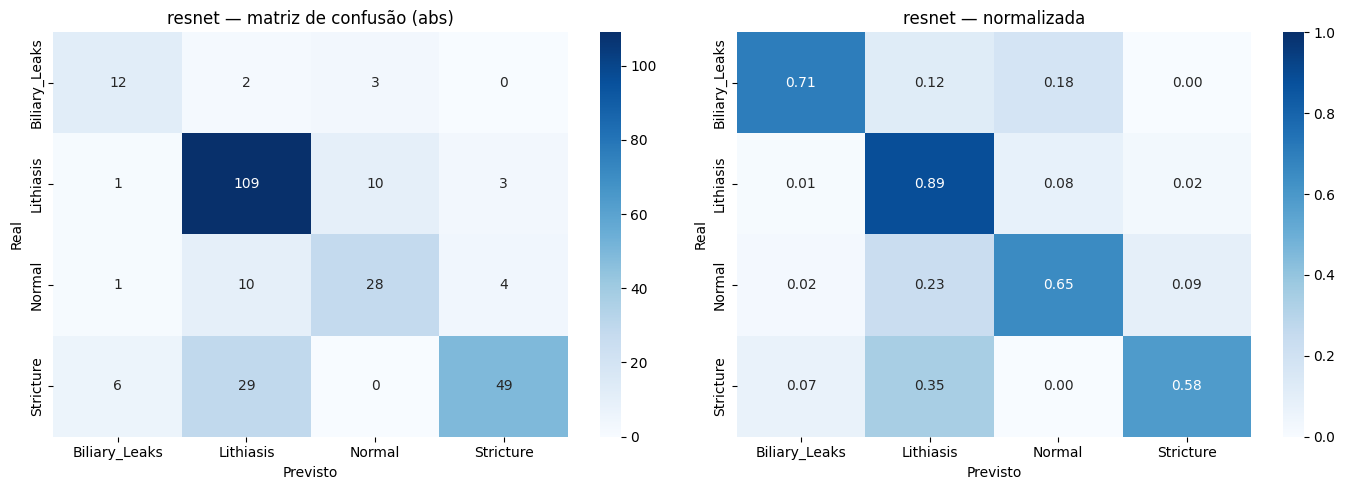

In [13]:
xgb_proba_test = best_xgb.predict_proba(X_test)
xgb_preds_test = xgb_proba_test.argmax(1)

f1_test = f1_score(y_test, xgb_preds_test, average='macro')
acc_test = accuracy_score(y_test, xgb_preds_test)
y_bin = label_binarize(y_test, classes=np.arange(NUM_CLASS))
try:
    auc_test = roc_auc_score(y_bin, xgb_proba_test, average='macro', multi_class='ovr')
except Exception:
    auc_test = float('nan')

print(f"\n{'='*60}")
print(f"{MODEL_TYPE.upper()} + XGBoost (TEST)")
print(f"{'='*60}")
print(f"  F1 macro  : {f1_test:.4f}    (CNN puro: {cnn_f1:.4f}  | baseline paper: 0.738)")
print(f"  Accuracy  : {acc_test:.4f}")
print(f"  AUC macro : {auc_test:.4f}")
print()
print(classification_report(y_test, xgb_preds_test, target_names=class_names, digits=4, zero_division=0))

cm  = confusion_matrix(y_test, xgb_preds_test)
cmn = confusion_matrix(y_test, xgb_preds_test, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'{MODEL_TYPE} — matriz de confusão (abs)'); axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'{MODEL_TYPE} — normalizada'); axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.savefig(f'./preds/{RUN_TAG}_cm.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
np.savez(f'./preds/{RUN_TAG}_predictions.npz',
         xgb_proba=xgb_proba_test,
         cnn_proba=cnn_proba_test,
         actuals=y_test,
         class_names=np.array(class_names),
         cnn_f1=cnn_f1,
         xgb_f1=f1_test,
         best_params=str(grid.best_params_))
print(f"Guardado em ./preds/{RUN_TAG}_predictions.npz")
print("-> mudar o CONFIG para outro modelo e voltar a correr de cima")

Guardado em ./preds/resnet_predictions.npz
-> mudar o CONFIG para outro modelo e voltar a correr de cima


## 7. Ensemble

Correr depois de ter os ficheiros `.npz` em `./preds/` para pelo menos 2 modelos.

In [15]:
# Ensemble misto: usa a melhor variante de cada modelo
custom_picks = {
    'densenet': 'cnn',       # 0.6207 > 0.5353
    'resnet': 'xgb',         # 0.7035 > 0.5682  <
    'efficientnet': 'cnn',   # 0.7381 > 0.6949
    'mobilenet': 'cnn',      # 0.5894 > 0.5842
}

probas_list = []
actuals_ref = None
for tag, kind in custom_picks.items():
    d = np.load(f'./preds/{tag}_predictions.npz', allow_pickle=True)
    probas_list.append(d[f'{kind}_proba'])
    if actuals_ref is None:
        actuals_ref = d['actuals']

ens_proba = np.mean(np.stack(probas_list, axis=0), axis=0)
ens_preds = ens_proba.argmax(1)
print(f"MIXED ENSEMBLE F1 macro = {f1_score(actuals_ref, ens_preds, average='macro'):.4f}")
print(classification_report(actuals_ref, ens_preds, target_names=class_names, digits=4))

# Pesos proporcionais ao F1 individual
weights = {'densenet': 0.6207, 'resnet': 0.7035, 'efficientnet': 0.7381, 'mobilenet': 0.5894}
W = np.array([weights[k] for k in custom_picks.keys()])
W = W / W.sum()
ens_proba_w = np.sum(np.stack(probas_list, axis=0) * W.reshape(-1, 1, 1), axis=0)
ens_preds_w = ens_proba_w.argmax(1)
print(f"WEIGHTED ENSEMBLE F1 macro = {f1_score(actuals_ref, ens_preds_w, average='macro'):.4f}")

MIXED ENSEMBLE F1 macro = 0.7797
               precision    recall  f1-score   support

Biliary_Leaks     0.8462    0.6471    0.7333        17
    Lithiasis     0.7820    0.8455    0.8125       123
       Normal     0.6610    0.9070    0.7647        43
    Stricture     0.9516    0.7024    0.8082        84

     accuracy                         0.7978       267
    macro avg     0.8102    0.7755    0.7797       267
 weighted avg     0.8199    0.7978    0.7984       267

WEIGHTED ENSEMBLE F1 macro = 0.7797


## 8. Grad-CAM

Corre depois de ter o último modelo carregado. Para o DeiT3 usa reshape_transform; para os outros usa o último bloco convolucional.

Requer: `pip install grad-cam`

## 9. Análise clínica — Stricture

Stricture é a classe mais grave (pode mascarar tumores malignos). Ajustamos o threshold da classe para aumentar o recall, mesmo que isso traga mais falsos positivos.

Índice de Stricture: 3

Threshold    Recall Stricture     F1 macro     Acc     
-------------------------------------------------------
0.10         0.9405               0.7271       0.7303
0.15         0.9167               0.7681       0.7828
0.20         0.9048               0.7898       0.8127
0.25         0.8452               0.7811       0.8052
0.30         0.8333               0.7855       0.8090
0.35         0.8214               0.7993       0.8240
0.40         0.7500               0.7857       0.8052

Threshold = 0.2
Recall Stricture : 0.7024  ->  0.9048  (Δ=+0.2024)
F1 macro         : 0.7797  ->  0.7898  (Δ=+0.0101)

=== Classification Report (threshold ajustado) ===
               precision    recall  f1-score   support

Biliary_Leaks     0.9167    0.6471    0.7586        17
    Lithiasis     0.8796    0.7724    0.8225       123
       Normal     0.6364    0.8140    0.7143        43
    Stricture     0.8261    0.9048    0.8636        84

     accuracy                         

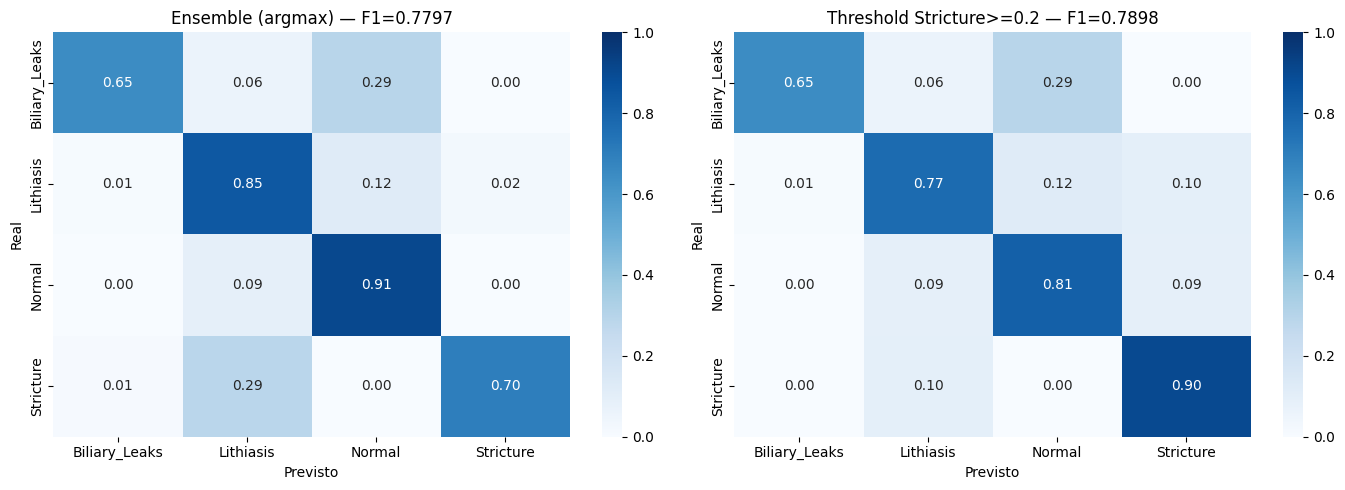

In [16]:
from sklearn.metrics import recall_score, classification_report

STRICTURE_IDX = class_names.tolist().index('Stricture') if hasattr(class_names, 'tolist') else list(class_names).index('Stricture')
print(f"Índice de Stricture: {STRICTURE_IDX}")

preds_baseline = ens_proba.argmax(1)
recall_baseline = recall_score(actuals_ref, preds_baseline, labels=[STRICTURE_IDX], average='macro')
f1_baseline     = f1_score(actuals_ref, preds_baseline, average='macro')

print(f"\n{'Threshold':<12} {'Recall Stricture':<20} {'F1 macro':<12} {'Acc':<8}")
print("-" * 55)
results_thresh = []
for thresh in np.arange(0.10, 0.45, 0.05):
    preds_adj = preds_baseline.copy()
    mask = ens_proba[:, STRICTURE_IDX] > thresh
    preds_adj[mask] = STRICTURE_IDX
    rec  = recall_score(actuals_ref, preds_adj, labels=[STRICTURE_IDX], average='macro')
    f1   = f1_score(actuals_ref, preds_adj, average='macro')
    acc  = accuracy_score(actuals_ref, preds_adj)
    print(f"{thresh:<12.2f} {rec:<20.4f} {f1:<12.4f} {acc:.4f}")
    results_thresh.append((thresh, rec, f1, acc))

STRICTURE_THRESHOLD = 0.20
preds_adjusted = preds_baseline.copy()
mask = ens_proba[:, STRICTURE_IDX] > STRICTURE_THRESHOLD
preds_adjusted[mask] = STRICTURE_IDX

recall_after = recall_score(actuals_ref, preds_adjusted, labels=[STRICTURE_IDX], average='macro')
f1_after     = f1_score(actuals_ref, preds_adjusted, average='macro')

print(f"\n{'='*55}")
print(f"Threshold = {STRICTURE_THRESHOLD}")
print(f"Recall Stricture : {recall_baseline:.4f}  ->  {recall_after:.4f}  (Δ={recall_after-recall_baseline:+.4f})")
print(f"F1 macro         : {f1_baseline:.4f}  ->  {f1_after:.4f}  (Δ={f1_after-f1_baseline:+.4f})")
print()
print("=== Classification Report (threshold ajustado) ===")
print(classification_report(actuals_ref, preds_adjusted, target_names=class_names, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(axes,
                             [preds_baseline, preds_adjusted],
                             [f'Ensemble (argmax) — F1={f1_baseline:.4f}',
                              f'Threshold Stricture>={STRICTURE_THRESHOLD} — F1={f1_after:.4f}']):
    cm = confusion_matrix(actuals_ref, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title); ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('./preds/stricture_threshold_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [17]:
### Sanity check — Biliary_Leaks (17 imagens no test)
BL_IDX = class_names.tolist().index('Biliary_Leaks') if hasattr(class_names, 'tolist') else list(class_names).index('Biliary_Leaks')

bl_indices = np.where(actuals_ref == BL_IDX)[0]
print(f"\n{'Idx':<5} {'GT':<15} {'Pred':<15} {'BL':<8} {'Li':<8} {'No':<8} {'St':<8} {'Análise'}")
print("-" * 90)

for i in bl_indices:
    probs = ens_proba[i]
    pred_idx = int(probs.argmax())
    sorted_idx = probs.argsort()[::-1]
    top1, top2 = probs[sorted_idx[0]], probs[sorted_idx[1]]

    if pred_idx == BL_IDX:
        status = "✅ acerto"
    elif (top1 - top2) < 0.15:
        status = f"⚠️  50/50 com {class_names[sorted_idx[1]]}"
    else:
        status = f"❌ confiante errado → {class_names[pred_idx]}"

    print(f"{i:<5} Biliary_Leaks  {class_names[pred_idx]:<15} "
          f"{probs[0]:.3f}   {probs[1]:.3f}   {probs[2]:.3f}   {probs[3]:.3f}   {status}")

print(f"\nTotal Biliary_Leaks no test : {len(bl_indices)}")
print(f"Acertos                     : {int((ens_proba[bl_indices].argmax(1) == BL_IDX).sum())}")
print(f"Confidence média na classe verdadeira    : {ens_proba[bl_indices, BL_IDX].mean():.3f}")
print(f"Confidence média na classe prevista (max): {ens_proba[bl_indices].max(1).mean():.3f}")

# Categorizar os erros
n_50_50  = sum(1 for i in bl_indices if int(ens_proba[i].argmax()) != BL_IDX and
               (ens_proba[i].max() - np.sort(ens_proba[i])[-2]) < 0.15)
n_conf   = sum(1 for i in bl_indices if int(ens_proba[i].argmax()) != BL_IDX and
               (ens_proba[i].max() - np.sort(ens_proba[i])[-2]) >= 0.15)
n_correct = int((ens_proba[bl_indices].argmax(1) == BL_IDX).sum())

print(f"\n--- Diagnóstico ---")
print(f"  Corretos        : {n_correct}/{len(bl_indices)}")
print(f"  Erros 50/50     : {n_50_50}  (modelo hesita — threshold ou mais dados resolvem)")
print(f"  Erros confiantes: {n_conf}  (modelo aprendeu mal esta classe)")
if ens_proba[bl_indices, BL_IDX].mean() < 0.20:
    print("  ⚠️  Probabilidade média em BL < 0.20 — subestimação sistemática")


Idx   GT              Pred            BL       Li       No       St       Análise
------------------------------------------------------------------------------------------
0     Biliary_Leaks  Biliary_Leaks   0.661   0.133   0.157   0.048   ✅ acerto
1     Biliary_Leaks  Biliary_Leaks   0.648   0.129   0.182   0.041   ✅ acerto
2     Biliary_Leaks  Biliary_Leaks   0.609   0.095   0.273   0.024   ✅ acerto
3     Biliary_Leaks  Lithiasis       0.329   0.510   0.096   0.065   ❌ confiante errado → Lithiasis
4     Biliary_Leaks  Biliary_Leaks   0.598   0.191   0.159   0.052   ✅ acerto
5     Biliary_Leaks  Biliary_Leaks   0.454   0.118   0.393   0.035   ✅ acerto
6     Biliary_Leaks  Biliary_Leaks   0.463   0.261   0.228   0.048   ✅ acerto
7     Biliary_Leaks  Biliary_Leaks   0.480   0.315   0.119   0.087   ✅ acerto
8     Biliary_Leaks  Biliary_Leaks   0.812   0.071   0.105   0.013   ✅ acerto
9     Biliary_Leaks  Biliary_Leaks   0.547   0.183   0.241   0.028   ✅ acerto
10    Biliary_Leaks  Nor

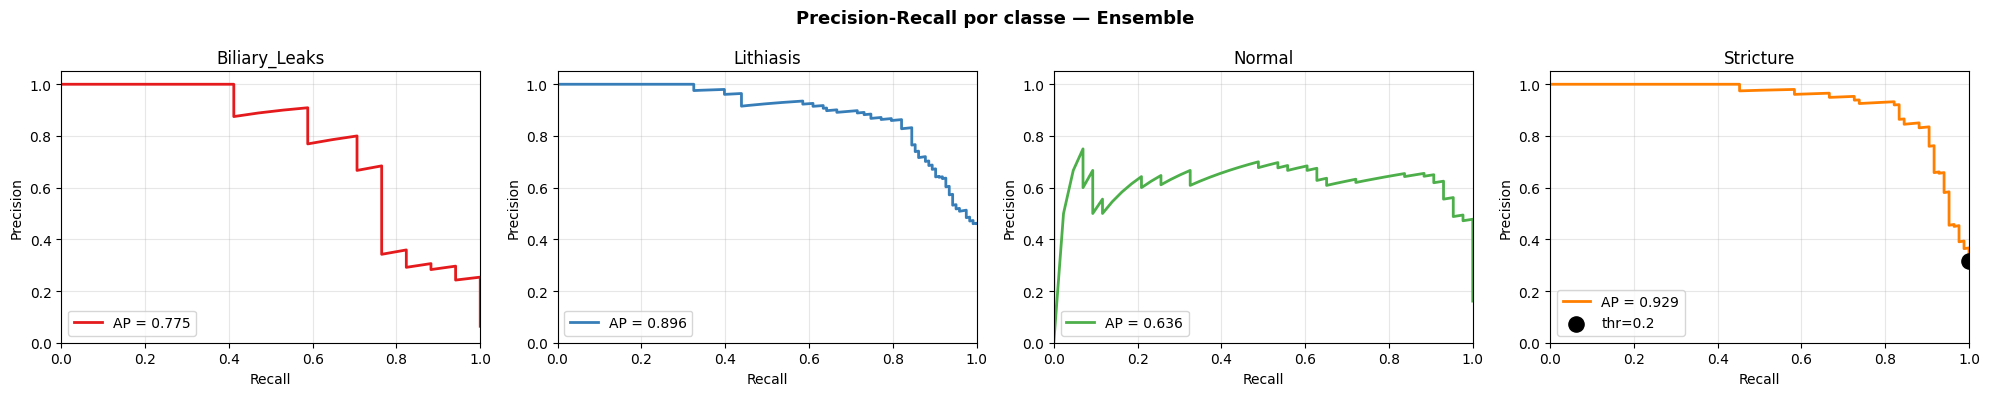

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(actuals_ref, classes=np.arange(NUM_CLASS))

fig, axes = plt.subplots(1, NUM_CLASS, figsize=(5 * NUM_CLASS, 4))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

for i, (ax, cls, color) in enumerate(zip(axes, class_names, colors)):
    precision, recall, thresholds = precision_recall_curve(y_bin[:, i], ens_proba[:, i])
    ap = average_precision_score(y_bin[:, i], ens_proba[:, i])
    ax.plot(recall, precision, color=color, lw=2, label=f'AP = {ap:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(cls); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.legend(loc='lower left'); ax.grid(alpha=0.3)

    if cls == 'Stricture':
        t_idx = np.searchsorted(thresholds[::-1], STRICTURE_THRESHOLD, side='left')
        t_idx = len(thresholds) - 1 - t_idx
        t_idx = max(0, min(t_idx, len(thresholds) - 1))
        ax.scatter(recall[t_idx], precision[t_idx], s=120, zorder=5, color='black',
                   label=f'thr={STRICTURE_THRESHOLD}')
        ax.legend(loc='lower left')

plt.suptitle('Precision-Recall por classe — Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./preds/pr_curve_by_class.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\bruno\AppData\Local\Temp\ipykernel_31312\3974452824.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gc_model.load_state_dict(torch.load(MODEL_PTH, map_location

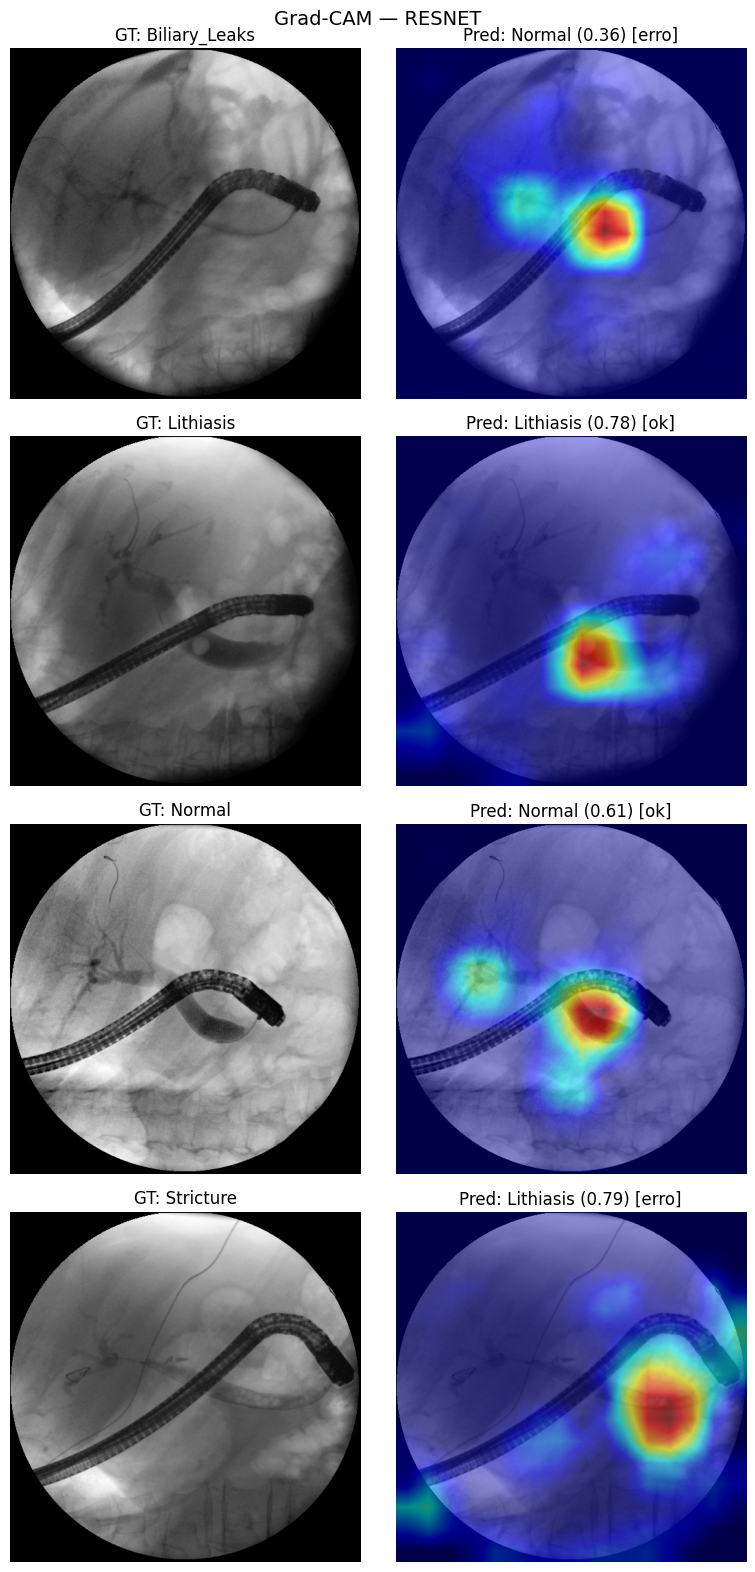

Grad-CAM guardado em ./preds/resnet_gradcam.png


In [19]:
if MODEL_TYPE == 'deit3':
    import timm
    gc_model = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)
    gc_model.head = nn.Linear(gc_model.head.in_features, NUM_CLASS)
    target_layers = [gc_model.blocks[-1].norm1]
    def reshape_transform(tensor, h=24, w=24):
        result = tensor[:, 1:, :].reshape(tensor.size(0), h, w, tensor.size(2))
        return result.permute(0, 3, 1, 2)
elif MODEL_TYPE == 'densenet':
    from monai.networks.nets import DenseNet121
    gc_model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=NUM_CLASS, pretrained=False)
    target_layers = [gc_model.features.denseblock4]
    reshape_transform = None
elif MODEL_TYPE == 'resnet':
    from torchvision.models import resnet50
    gc_model = resnet50(weights=None)
    gc_model.fc = nn.Linear(gc_model.fc.in_features, NUM_CLASS)
    target_layers = [gc_model.layer4[-1]]
    reshape_transform = None
elif MODEL_TYPE == 'efficientnet':
    from torchvision.models import efficientnet_b7
    gc_model = efficientnet_b7(weights=None)
    gc_model.classifier[1] = nn.Linear(gc_model.classifier[1].in_features, NUM_CLASS)
    target_layers = [gc_model.features[-1]]
    reshape_transform = None
elif MODEL_TYPE == 'mobilenet':
    from torchvision.models import mobilenet_v2
    gc_model = mobilenet_v2(weights=None)
    gc_model.classifier[1] = nn.Linear(gc_model.classifier[1].in_features, NUM_CLASS)
    target_layers = [gc_model.features[-1]]
    reshape_transform = None

gc_model.load_state_dict(torch.load(MODEL_PTH, map_location=device))
gc_model = gc_model.to(device).eval()

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

if reshape_transform is not None:
    cam = GradCAM(model=gc_model, target_layers=target_layers, reshape_transform=reshape_transform)
else:
    cam = GradCAM(model=gc_model, target_layers=target_layers)

# uma imagem por classe do conjunto de teste
idx_by_class = {c: None for c in range(NUM_CLASS)}
for i, lbl in enumerate(data['test']['labels']):
    if idx_by_class[lbl] is None:
        idx_by_class[lbl] = i

fig, axes = plt.subplots(NUM_CLASS, 2, figsize=(8, 4*NUM_CLASS))
test_ds = ERCPDataset(data['test']['images'], data['test']['labels'], inference_transforms)

for c_idx in range(NUM_CLASS):
    t_idx = idx_by_class[c_idx]
    img_tensor, true_lbl = test_ds[t_idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = gc_model(input_tensor)
        pred = int(logits.argmax(1).item())
        prob = float(F.softmax(logits, dim=1).max().item())

    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred)])[0]
    rgb_img = img_tensor.cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-6)
    rgb_img = rgb_img.transpose(1, 2, 0)
    rgb_img = np.clip(rgb_img, 0, 1)
    cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[c_idx, 0].imshow(rgb_img); axes[c_idx, 0].axis('off')
    axes[c_idx, 0].set_title(f"GT: {class_names[true_lbl]}")
    axes[c_idx, 1].imshow(cam_img); axes[c_idx, 1].axis('off')
    ok = "ok" if pred == true_lbl else "erro"
    axes[c_idx, 1].set_title(f"Pred: {class_names[pred]} ({prob:.2f}) [{ok}]")

plt.suptitle(f"Grad-CAM — {MODEL_TYPE.upper()}", fontsize=14)
plt.tight_layout()
plt.savefig(f'./preds/{RUN_TAG}_gradcam.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Grad-CAM guardado em ./preds/{RUN_TAG}_gradcam.png")